In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
print(df.shape)
print()
print(df.dtypes)
print()
print("Missing values:\n", df.isna().sum())
print()
print("Duplicate userids:", df["userid"].duplicated().sum())
print()
print(df["version"].value_counts())

(90189, 5)

userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object

Missing values:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate userids: 0

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [7]:
print(df["sum_gamerounds"].describe())
print()
print(df["sum_gamerounds"].quantile([0.5, 0.9, 0.99, 0.999]))
print()
print("Players with 0 rounds:", (df["sum_gamerounds"] == 0).sum())
print()
df.nlargest(5, "sum_gamerounds")

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

0.500      16.000
0.900     134.000
0.990     493.000
0.999    1073.624
Name: sum_gamerounds, dtype: float64

Players with 0 rounds: 3994



,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


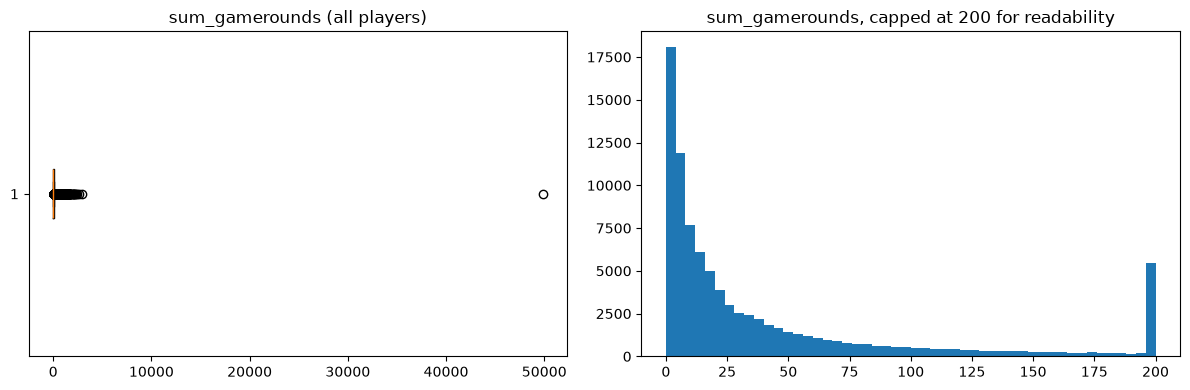

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df["sum_gamerounds"], orientation="horizontal")
axes[0].set_title("sum_gamerounds (all players)")
axes[1].hist(df["sum_gamerounds"].clip(upper=200), bins=50)
axes[1].set_title("sum_gamerounds, capped at 200 for readability")
plt.tight_layout()
plt.show()

## Exploration notes
- 90,189 players, no missing values, no duplicate userids.
- Groups: gate_30 = 44,700, gate_40 = 45,489.
- sum_gamerounds is right-skewed (median 16, mean 51.9, 99th pct 493).
- One extreme outlier (49,854 rounds, next highest 2,961), likely a logging error.
- 3,994 players played 0 rounds; kept because they were randomised.